In [1]:
import h5py as h5
import numpy as np

import matplotlib.pyplot as plt

## This is just a container for our global variables

Any time you want to add one, just add a keyword argument to where the `Arguments` is initialized. This is helpful since it will keep our namespace from getting cluttered.

In [2]:
class Arguments:
    def __init__(self, **kwargs):
        self.__dict__.update(kwargs)

args = Arguments(
    infile = "../resources/digitized_reco_angles.h5",
)

## Let's poke at the input file a bit

We'll be using an HDF5 file. I like these very much, but I will save boring you with my praises for another time.

In [3]:
with h5.File(args.infile) as h5f:
    print(h5f.keys())

<KeysViewHDF5 ['results_1', 'results_2', 'results_3', 'results_4', 'results_5']>


It looks like there are 5 different `Group`s that hold `Dataset`s. Maybe we can peak at what the datasets look like

In [4]:
with h5.File(args.infile) as h5f:
    print(h5f["results_1"].keys())

<KeysViewHDF5 ['psi', 'value']>


So there are two different `Dataset`s for each group. We can go ahead and plot the data to see what it looks like

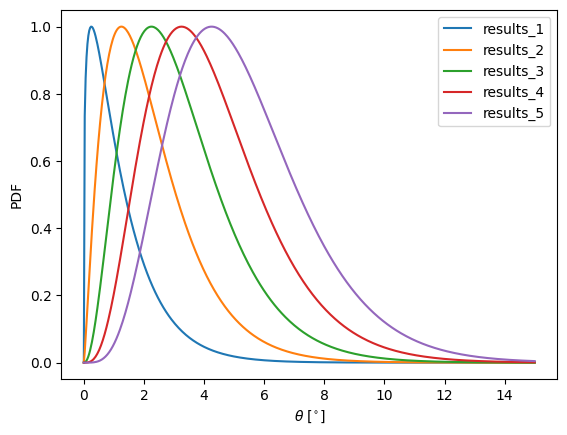

In [5]:
with h5.File(args.infile) as h5f:
    for k, v in h5f.items():
        plt.plot(v["psi"][:], v["value"][:], label=k)
        
plt.xlabel(r"$\theta~\left[^{\circ}\right]$")
plt.ylabel(r"PDF")
plt.legend()
plt.show()

I made these datasets artificially, so I can say that each distribution is proportional to the _probability density function_ (PDF) of getting a certain misreconstruction angle. We could think of each curve as corresponding to a different neutrino energy.

# Sampling from these distributions

We need to be able to sample from arbitrarily shaped distributions. This will proceed in $N$ steps:

1. Compute the total integral of the distribution
2. Obtain a _cumulative distribution function_ (CDF)
3. Invert the CDF
4. Sample

## 1. Compute the total integral of the distribution

We only have the distribution evaluated at a finite number of points; however, there is some underlying function that these are values of. We are going to interpolate the points and then compute the integral.

In [6]:
from scipy.interpolate import interp1d
from scipy.integrate import quad

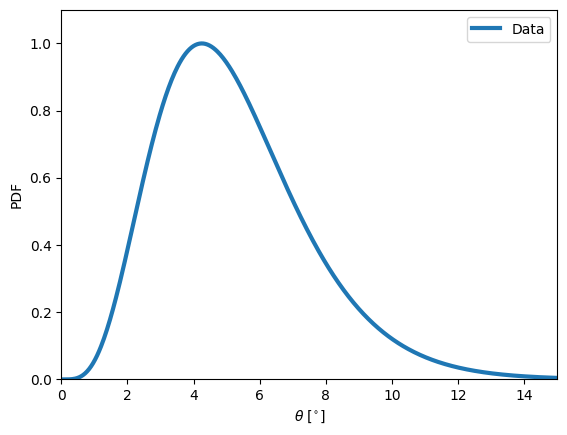

In [15]:

with h5.File(args.infile) as h5f:
    xs = h5f["results_5/psi"][:]
    ys = h5f["results_5/value"][:]
    f = interp1d(xs, ys)
    
# Plot it just to make sure the interpolation didn't break
plt.plot(xs, ys, lw=3, label="Data")
# plt.plot(xs, f(xs), label="Interpolated")
plt.xlabel(r"$\theta~\left[^{\circ}\right]$")
plt.ylabel(r"PDF")
plt.xlim(0, 15)
plt.ylim(0, 1.1)
plt.legend()
plt.savefig("../figures/1d_sampling_demo_pdf.pdf")
plt.show()

In [11]:
i, err = quad(f, xs[0], xs[-1])
print(i)
print(err / i)

5.263585138542076
1.1771496652444458e-05


/var/folders/rr/4sp_7qnn509b31qkr6c2_6sr0000gp/T/ipykernel_70440/2393064499.py:1: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  i, err = quad(f, xs[0], xs[-1])


## 2. Convert this to a CDF

/var/folders/rr/4sp_7qnn509b31qkr6c2_6sr0000gp/T/ipykernel_70440/1773409747.py:5: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  cdf_values = np.array([quad(f, 0, x)[0] / i for x in xs])
/var/folders/rr/4sp_7qnn509b31qkr6c2_6sr0000gp/T/ipykernel_70440/1773409747.py:5: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  cdf_values = np.array([quad(f, 0, x)[0] / i for x in xs])


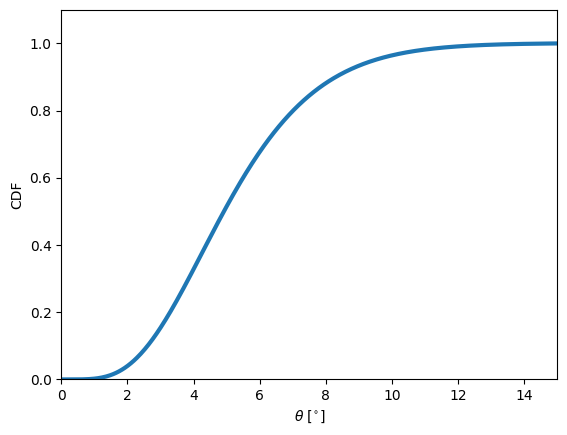

In [31]:
# try:
#     cdf_values
# except NameError:
#     cdf_values = np.array([quad(f, 0, x)[0] / i for x in xs])
cdf_values = np.array([quad(f, 0, x)[0] / i for x in xs])

    
plt.plot(xs, cdf_values, lw=3)
plt.xlabel(r"$\theta~\left[^{\circ}\right]$")
plt.ylabel(r"CDF")
plt.xlim(0, 15)
plt.ylim(0, 1.1)
plt.savefig("../figures/1d_sampling_demo_cdf.pdf")

plt.show()

### Tangent: there's more than one way to skin a cat

In [ ]:
plt.plot(xs, cdf_values, label="Properly computed", ls="--", lw=3)
plt.plot(xs, np.cumsum(ys) / ys.sum(), label="Sneakily computed")
plt.legend()
plt.xlabel(r"$\theta~\left[^{\circ}\right]$")
plt.ylabel(r"CDF")
plt.show()

## 3. Invert the CDF

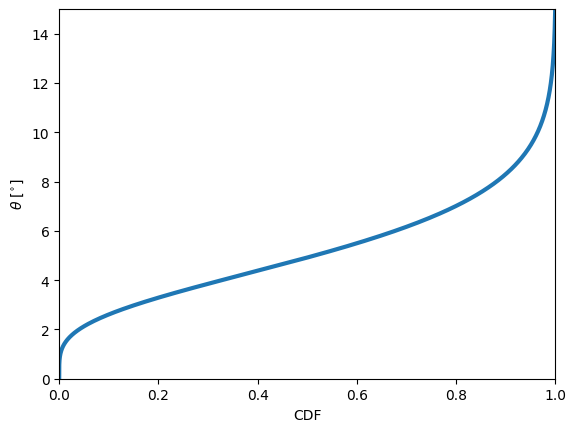

In [32]:
cdf_inv = interp1d(cdf_values, xs)
plt.plot(cdf_values, xs, label="Data", lw=3)
# plt.plot(cdf_values, cdf_inv(cdf_values), label="Interpolation")

plt.xlabel(r"CDF")
plt.ylabel(r"$\theta~\left[^{\circ}\right]$")
plt.ylim(0, 15)
plt.xlim(0, 1)
plt.savefig("../figures/1d_sampling_demo_inv_cdf.pdf")
plt.show()

## 4. Sample from the CDF

My claim is that by taking numbers drawn uniformly between 0 and 1 and evaulating the inverse CDF on them, we will reproduce the input distribution. Below are some plots to perhaps convince you this is true. We will start by sampling 20 numbers

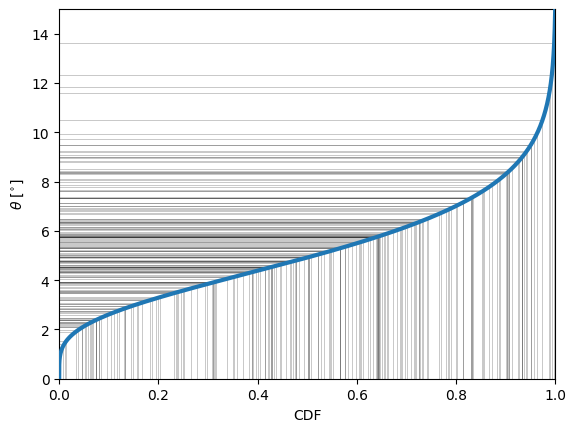

In [30]:
us = np.random.rand(200)

fig, ax = plt.subplots()

ax.plot(cdf_values, xs, label="Data", lw=3, zorder=10)

ax.set_xlabel(r"CDF")
ax.set_ylabel(r"$\theta~\left[^{\circ}\right]$")
ax.set_xlim(0, 1)
ax.set_ylim(0, 15)

for idx, u in enumerate(us):
    ax.axvline(u, ymin=0, ymax=cdf_inv(u) / 15, lw=0.5, c="k", alpha=0.3, zorder=1)
    ax.axhline(cdf_inv(u), xmin=0, xmax=u, lw=0.5, c="k", alpha=0.3, zorder=1)

    file_idx = f'{idx:03}'
    plt.savefig(f"../figures/1d_sampling_demo_sampling_{file_idx}.png")


plt.show()

Clearly these are clustering near the lower end of the distribution, but let's kick it up a notch.

In [ ]:
us = np.random.rand(1_000)
for u in us:
    plt.axvline(u, ymin=0, ymax=cdf_inv(u) / 15, lw=0.5, c="k", alpha=0.1)
    plt.axhline(cdf_inv(u), xmin=0, xmax=u, lw=0.5, c="k", alpha=0.1)
    
plt.plot(cdf_values, xs, label="Data")

plt.xlabel(r"CDF")
plt.ylabel(r"$\theta~\left[^{\circ}\right]$")
plt.xlim(0, 1)
plt.ylim(0, 15)
plt.show()

That's definitely something ! notice how the lines are pretty uniform on the $x$-axis, but they clump up properly on the $y$-axis. Let's make some historgrams now :-) 

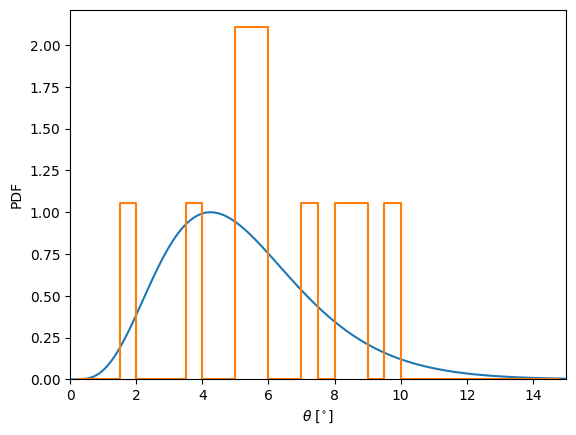

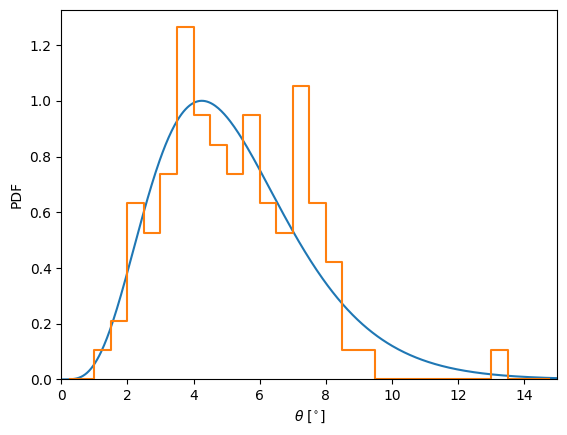

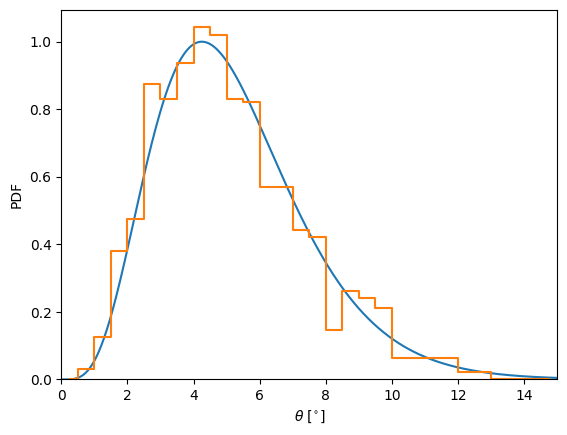

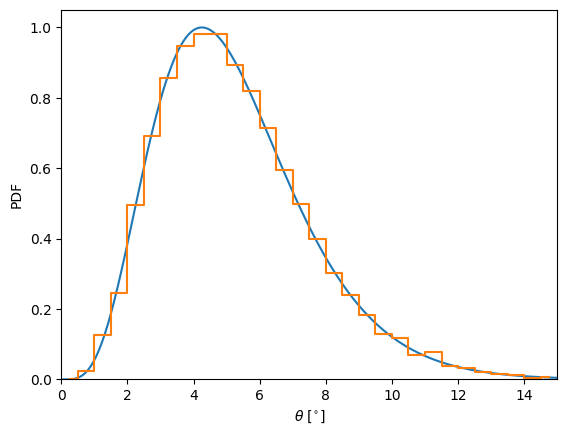

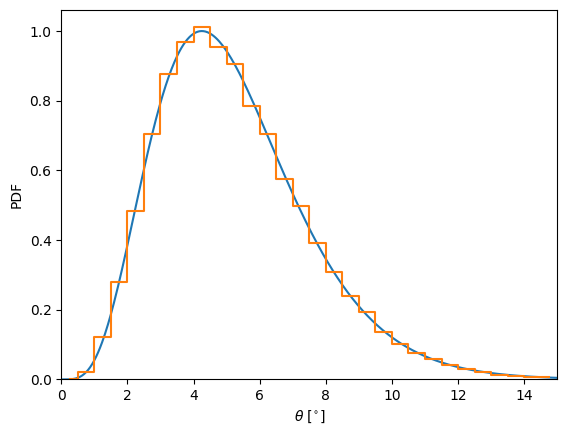

In [40]:
bins = np.linspace(0, 15, 31)
centers = (bins[1:] + bins[:-1]) / 2

for nsample in [10, 100, 1_000, 10_000, 100_000]:
    us = np.random.rand(nsample)
    vs = cdf_inv(us)
    h, _ = np.histogram(vs, bins=bins)
    plt.plot(xs, ys, label="PDF")
    plt.step(centers, h / h.sum() / np.diff(bins) * i, where="mid", label=nsample)
    plt.xlabel(r"$\theta~\left[^{\circ}\right]$")
    plt.ylabel(r"PDF")
    plt.xlim(0, 15)
    plt.ylim(0, None)
    # plt.legend()
    plt.savefig(f"../figures/1d_sampling_demo_pdf_compare_{nsample}.pdf")
    plt.show()

As you can see, as we draw more samples, the historgram gets closer to the expected distribution. You can make sure that this works for the other keys in the file as a little exercise.